# Unsupervised Learning Project
## Module E4 - PCA / SVD Study for Clustering (Representation Learning)

**Team (G4-P2):** José Nunes (73137) · João Lourenço (72904) · Leonor Afonso (73491)

**Course:** Unsupervised Learning · 2025/2026 · NOVA FCT, Departamento de Informática

---

**Module E4 Overview:**  
This notebook studies whether **linear dimensionality reduction (PCA)** provides a useful pre-processing step for clustering the TA/TO booking sub-population originally analysed in Tasks 1 and 2. The central question is:

> *Does projecting representation R0 into a lower-dimensional PCA subspace improve, preserve, or degrade the clustering structure found in Tasks 1 and 2?*

**Key methodological caveat (declared up front):** PCA maximises retained variance, not cluster separability. The directions of maximum variance and the directions that best separate clusters are generally **not the same**. We therefore cannot assume that a PCA projection that retains, say, 90% of variance will also retain 90% of the cluster structure. This module provides empirical evidence bearing on this question.

> **Note:** This notebook reproduces the exact preprocessing pipeline from Task 1 (`ANS_Task1.ipynb`) so it can be executed independently. All constants (`SEED`, `SUBSAMPLE_N`, `SEEDS_STABILITY`, `REPRESENTATION_ID`, feature lists, cleaning steps) are identical to Tasks 1 and 2.

## 1. Environment, Imports and Reproducibility

In [ ]:
import os
import time
import hashlib
import warnings
from pathlib import Path
from itertools import combinations
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score,
)

# Reproducibility (identical to Tasks 1 & 2)
SEED            = 12345
SEEDS_STABILITY = [12345, 23456, 34567, 45678, 56789]
SUBSAMPLE_N     = 10_000   # Silhouette subsample (O(n²) management)
np.random.seed(SEED)

# Project layout (identical to Tasks 1 & 2)
def _find_project_root(markers=('requirements.txt', '.git', 'environment.yml')):
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if any((candidate / m).exists() for m in markers):
            return candidate
    return here

PROJECT_ROOT = _find_project_root()
DATA_DIR     = PROJECT_ROOT / 'data' / 'raw'
RESULTS_DIR  = PROJECT_ROOT / 'results'
FIG_DIR      = RESULTS_DIR / 'figures'
TBL_DIR      = RESULTS_DIR / 'tables'
RPT_DIR      = RESULTS_DIR / 'reports'

for d in (FIG_DIR, TBL_DIR, RPT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Plot defaults
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10,
})
sns.set_style('whitegrid')

print("Environment ready.")
print(f"Project root         : {PROJECT_ROOT}")
print(f"Master seed          : {SEED}")
print(f"Stability seeds      : {SEEDS_STABILITY}")
print(f"Silhouette subsample : {SUBSAMPLE_N:,}")

Environment ready.
Project root         : C:\Users\joaol\Documents\GitHub\hotel_booking_demand
Master seed          : 12345
Stability seeds      : [12345, 23456, 34567, 45678, 56789]
Silhouette subsample : 10,000


## 2. Reproduce Task 1 Pipeline (Shared Setup)

All steps below are **identical to Tasks 1 and 2**: dataset load, sub-population filter, feature engineering, cleaning, rare-category grouping, and the R0 preprocessing pipeline. This guarantees that the matrix `X_R0` fed into PCA is byte-for-byte the same as in previous tasks.

In [ ]:
# Load dataset
DATASET_PATH = DATA_DIR / 'hotel_bookings.csv'

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATASET_PATH}. "
        f"Place hotel_bookings.csv in {DATA_DIR} (the data/raw folder of the repo)."
    )

with open(DATASET_PATH, 'rb') as f:
    DATASET_MD5 = hashlib.md5(f.read()).hexdigest()

df_raw = pd.read_csv(DATASET_PATH)
print(f"Dataset MD5  : {DATASET_MD5}")
print(f"Shape        : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

Dataset MD5  : cfa4d278475915ee56c9cb94a74ed3c5
Shape        : 119,390 rows × 32 columns


In [ ]:
# Sub-population filter: TA/TO bookings only
df = df_raw[df_raw['distribution_channel'] == 'TA/TO'].copy()
n_total, n_kept = len(df_raw), len(df)
print(f"Total raw records          : {n_total:,}")
print(f"TA/TO records (kept)       : {n_kept:,} ({n_kept/n_total*100:.1f}%)")
print(f"Excluded (other channels)  : {n_total - n_kept:,}")

Total raw records          : 119,390
TA/TO records (kept)       : 97,870 (82.0%)
Excluded (other channels)  : 21,520


In [ ]:
# Feature engineering and cleaning (identical to Task 1)
n0 = len(df)

# Engineered features
df['party_size']    = df['adults'] + df['children'].fillna(0) + df['babies']
df['total_nights']  = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['weekend_share'] = np.where(
    df['total_nights'] > 0,
    df['stays_in_weekend_nights'] / df['total_nights'], 0.0
)

# Drop zero-guest rows
df = df[df['party_size'] > 0].copy()
print(f"Start (TA/TO sub-population) : {n0:,}")
print(f"After dropping party_size==0 : {len(df):,}  (removed {n0-len(df):,})")

# Impute
df['country']  = df['country'].fillna('PRT')
df['children'] = df['children'].fillna(0)
df['party_size'] = df['adults'] + df['children'] + df['babies']  # recompute

# Cap count variables (P99 / domain ceiling)
df['previous_cancellations']         = df['previous_cancellations'].clip(
    upper=df['previous_cancellations'].quantile(0.99))
df['previous_bookings_not_canceled'] = df['previous_bookings_not_canceled'].clip(
    upper=df['previous_bookings_not_canceled'].quantile(0.99))
df['required_car_parking_spaces']    = df['required_car_parking_spaces'].clip(upper=3)
df['total_of_special_requests']      = df['total_of_special_requests'].clip(upper=5)

# Rare-category grouping (1% threshold)
RARE_THRESHOLD = 0.01
CAT_FEATURES   = ['market_segment', 'reserved_room_type', 'meal',
                   'customer_type', 'deposit_type', 'country', 'arrival_date_month']

print(f"\nRare-category grouping (< {RARE_THRESHOLD*100:.0f}% threshold):")
for col in CAT_FEATURES:
    freq = df[col].value_counts(normalize=True)
    rare = freq[freq < RARE_THRESHOLD].index.tolist()
    if rare:
        df[col] = df[col].where(~df[col].isin(rare), other='Other')
        print(f"  {col:25s}: grouped {len(rare):>3d} levels → 'Other'")
    else:
        print(f"  {col:25s}: no rare categories")

print(f"\nFinal MAIN sub-population (R0) : {len(df):,}")

Start (TA/TO sub-population) : 97,870
After dropping party_size==0 : 97,750  (removed 120)

Rare-category grouping (< 1% threshold):
  market_segment           : grouped   4 levels → 'Other'
  reserved_room_type       : grouped   3 levels → 'Other'
  meal                     : grouped   2 levels → 'Other'
  customer_type            : grouped   1 levels → 'Other'
  deposit_type             : grouped   1 levels → 'Other'
  country                  : grouped 160 levels → 'Other'
  arrival_date_month       : no rare categories

Final MAIN sub-population (R0) : 97,750


In [ ]:
# Build R0 matrix (identical to Task 1)
NUM_FEATURES_NUM = ['lead_time',
                    'previous_cancellations', 'previous_bookings_not_canceled',
                    'total_nights', 'weekend_share', 'party_size',
                    'required_car_parking_spaces', 'total_of_special_requests']
NUM_FEATURES_BIN = ['is_repeated_guest']

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
numeric_bin_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor_R0 = ColumnTransformer(
    transformers=[
        ('num',     numeric_pipe,     NUM_FEATURES_NUM),
        ('num_bin', numeric_bin_pipe, NUM_FEATURES_BIN),
        ('cat',     cat_pipe,         CAT_FEATURES),
    ],
    remainder='drop',
)

t0   = time.time()
X_R0 = preprocessor_R0.fit_transform(df)
t_prep = time.time() - t0

ohe           = preprocessor_R0.named_transformers_['cat']['onehot']
cat_names     = ohe.get_feature_names_out(CAT_FEATURES).tolist()
feature_names_R0 = NUM_FEATURES_NUM + NUM_FEATURES_BIN + cat_names

REPRESENTATION_ID = 'R0-standard-noLog-noADR-marketSegment-countryRare1pct'

print(f"Preprocessing completed in {t_prep:.2f}s")
print(f"R0 matrix shape : {X_R0.shape[0]:,} rows × {X_R0.shape[1]} columns")
print(f"  ({len(NUM_FEATURES_NUM)} numerical + {len(NUM_FEATURES_BIN)} binary + {len(cat_names)} one-hot)")
print(f"representation_id : {REPRESENTATION_ID}")

Preprocessing completed in 0.25s
R0 matrix shape : 97,750 rows × 57 columns
  (8 numerical + 1 binary + 48 one-hot)
representation_id : R0-standard-noLog-noADR-marketSegment-countryRare1pct


## 3. DR Approach Choice and Justification

### Why PCA (not TruncatedSVD)?

The R0 matrix is a **dense float64 array** produced by `ColumnTransformer` with `sparse_output=False`. Both dense numerical columns (8 StandardScaler-scaled features + 1 binary) and dense one-hot columns contribute. There is no computational benefit from the sparse-matrix arithmetic of `TruncatedSVD`: the matrix is already materialised in memory as a dense array.

**PCA** is therefore the natural choice:
- It centres the data before computing the SVD of the covariance matrix, ensuring that one-hot columns (with non-zero means) do not create a dominant first component that merely captures the grand mean shift.
- It returns components with a direct explained-variance interpretation, enabling the scree plot and the cumulative-variance plot to guide the choice of retained dimensionality.
- `TruncatedSVD` (without centring) is the appropriate choice when working with a *raw* one-hot / TF-IDF sparse matrix where centring would destroy sparsity. That is not our situation.

### When TruncatedSVD would be preferred

Had the representation been constructed as a **sparse** `scipy.sparse.csr_matrix` (e.g. via `OneHotEncoder(sparse_output=True)` without a dense downstream step), `TruncatedSVD` would have been the correct tool because it avoids materialising the full dense matrix in memory.

### Caveat (methodological, declared before fitting)

> **Variance preservation ≠ cluster-direction preservation.** PCA finds the orthogonal directions of maximum total variance. Cluster-separating directions are the directions along which *between-cluster* variance is maximised relative to *within-cluster* variance — the criterion of Linear Discriminant Analysis (LDA), not PCA. Because PCA is unsupervised with respect to cluster membership, it may project away exactly the dimensions that best discriminate the clusters, particularly when cluster-separating signal sits in low-variance directions (e.g. rare but diagnostically important one-hot features). We test this empirically below by comparing clustering quality before and after projection.

## 4. Scree Plot and Retained Dimensionality

We fit a full PCA (all components) to quantify how variance is distributed across the principal axes. The retained dimensionality `N_COMPONENTS` is chosen by the **90% cumulative explained-variance threshold** — a standard, defensible, and pre-declared rule. We also record the 80% and 95% thresholds for comparison.

In [ ]:
# Full PCA to study explained variance
t0  = time.time()
pca_full = PCA(random_state=SEED)
pca_full.fit(X_R0)
t_pca = time.time() - t0

ev_ratio  = pca_full.explained_variance_ratio_
ev_cumsum = np.cumsum(ev_ratio)
n_components_total = len(ev_ratio)

# Thresholds
k_80 = int(np.searchsorted(ev_cumsum, 0.80)) + 1
k_90 = int(np.searchsorted(ev_cumsum, 0.90)) + 1
k_95 = int(np.searchsorted(ev_cumsum, 0.95)) + 1

print(f"Full PCA fitted in {t_pca:.2f}s")
print(f"Total components : {n_components_total}")
print(f"Components for 80% EVR : {k_80}")
print(f"Components for 90% EVR : {k_90}  ← chosen threshold")
print(f"Components for 95% EVR : {k_95}")
print(f"\nVariance retained by first 5 PCs  : {ev_cumsum[4]:.3f}")
print(f"Variance retained by first 10 PCs : {ev_cumsum[9]:.3f}")
print(f"Variance retained by first 20 PCs : {ev_cumsum[19]:.3f}")

Full PCA fitted in 0.02s
Total components : 57
Components for 80% EVR : 11
Components for 90% EVR : 21  ← chosen threshold
Components for 95% EVR : 28

Variance retained by first 5 PCs  : 0.547
Variance retained by first 10 PCs : 0.781
Variance retained by first 20 PCs : 0.899


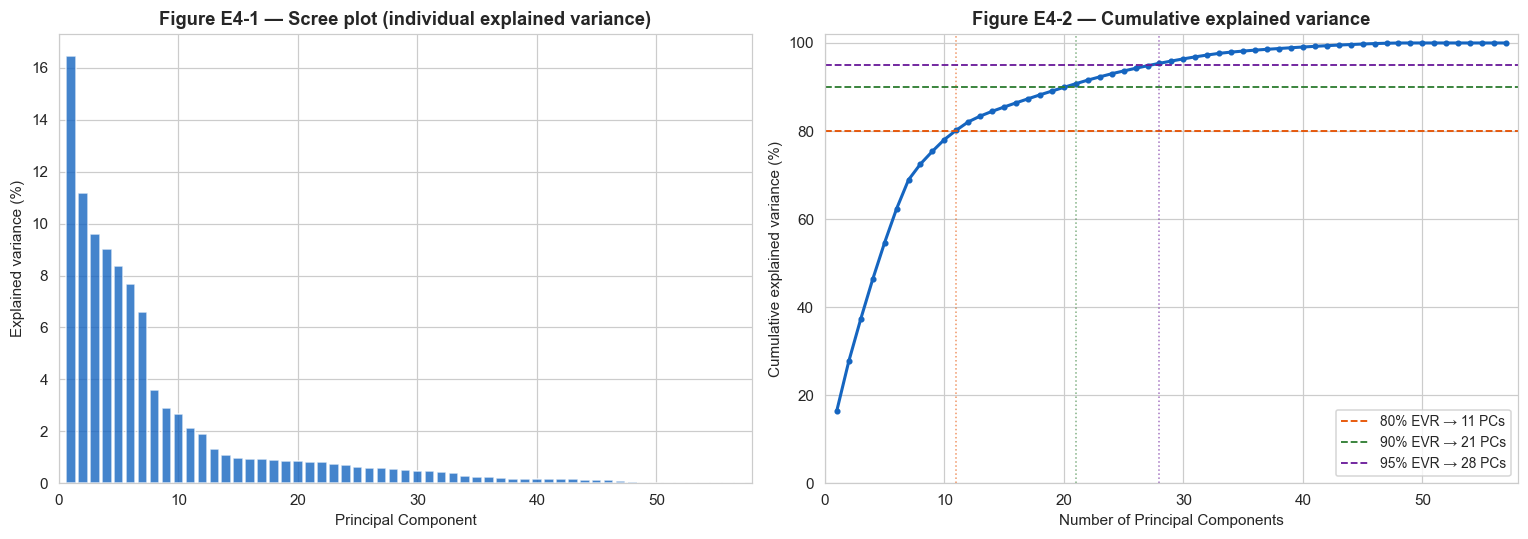


Chosen retained dimensionality : N_COMPONENTS = 21 (90% EVR threshold)


In [ ]:
# Scree plot + cumulative variance
PLOT_N = min(60, n_components_total)  # show first 60 components

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: individual explained variance (scree)
ax = axes[0]
ax.bar(range(1, PLOT_N + 1), ev_ratio[:PLOT_N] * 100,
       color='#1565C0', alpha=0.8, edgecolor='white')
ax.set_title('Figure E4-1 — Scree plot (individual explained variance)',
             fontweight='bold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained variance (%)')
ax.set_xlim(0, PLOT_N + 1)

# Right: cumulative explained variance
ax2 = axes[1]
ax2.plot(range(1, PLOT_N + 1), ev_cumsum[:PLOT_N] * 100,
         color='#1565C0', linewidth=2, marker='o', markersize=3)
for threshold, k_val, col, lab in [
    (80, k_80, '#E65100', '80%'),
    (90, k_90, '#2E7D32', '90%'),
    (95, k_95, '#6A1B9A', '95%'),
]:
    ax2.axhline(threshold, color=col, linestyle='--', linewidth=1.2,
                label=f'{lab} EVR → {k_val} PCs')
    ax2.axvline(k_val, color=col, linestyle=':', linewidth=1.0, alpha=0.6)

ax2.set_title('Figure E4-2 — Cumulative explained variance', fontweight='bold')
ax2.set_xlabel('Number of Principal Components')
ax2.set_ylabel('Cumulative explained variance (%)')
ax2.set_xlim(0, PLOT_N + 1)
ax2.set_ylim(0, 102)
ax2.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'figE4_1_2_scree_cumvar.png')
plt.show()

print(f"\nChosen retained dimensionality : N_COMPONENTS = {k_90} (90% EVR threshold)")

In [ ]:
# Fit PCA with retained dimensionality and project
N_COMPONENTS = k_90  # declared from the 90% EVR threshold above

t0 = time.time()
pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
X_PCA = pca.fit_transform(X_R0)
t_proj = time.time() - t0

evr_retained = pca.explained_variance_ratio_.sum()

print(f"PCA projection completed in {t_proj:.2f}s")
print(f"Original dimensionality : {X_R0.shape[1]}")
print(f"Reduced dimensionality  : {X_PCA.shape[1]}  ({N_COMPONENTS} components)")
print(f"Explained variance retained : {evr_retained*100:.2f}%")
print(f"Compression ratio : {X_R0.shape[1] / N_COMPONENTS:.1f}×")

PCA projection completed in 0.04s
Original dimensionality : 57
Reduced dimensionality  : 21  (21 components)
Explained variance retained : 90.75%
Compression ratio : 2.7×


## 5. PCA Loading Inspection

Before clustering in the reduced space, we inspect which original features drive the first few principal components. This (a) provides qualitative evidence about what structure PCA is capturing, and (b) flags whether cluster-separating information (e.g. booking channel, seasonality) loads strongly onto the retained components.

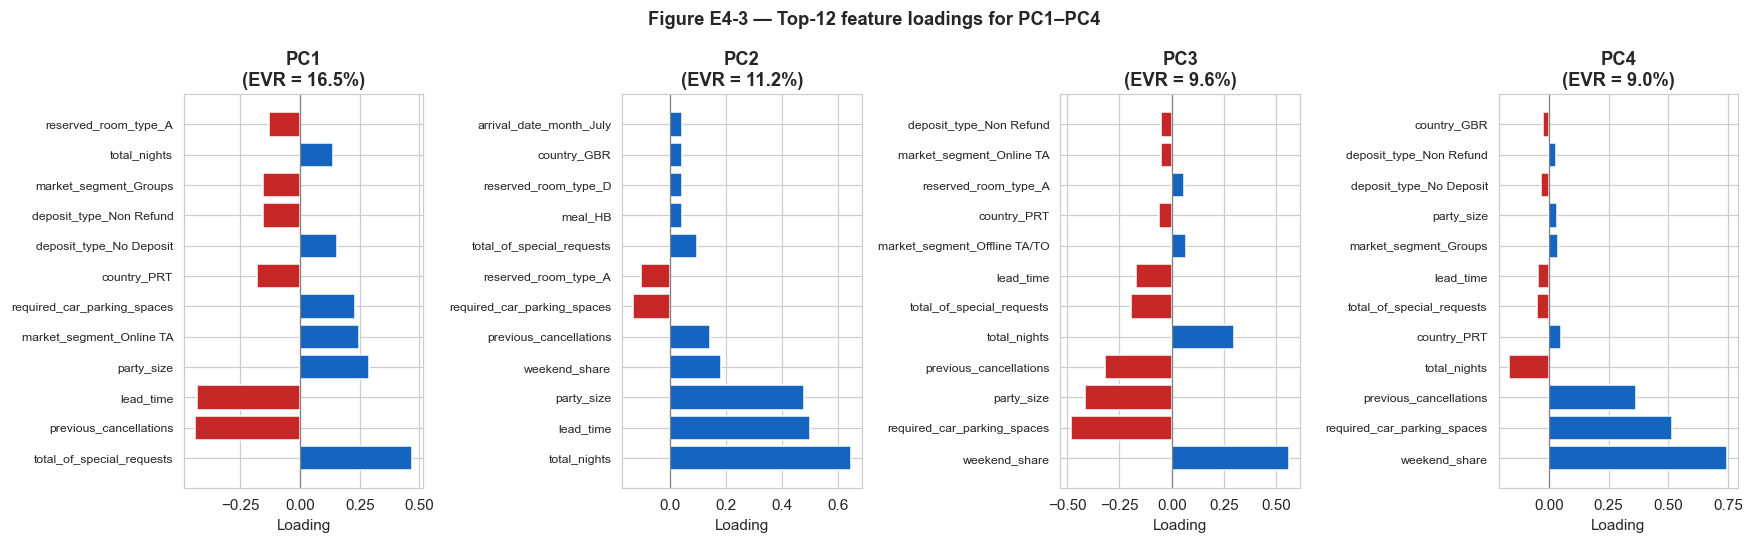

Loading table saved to tables/pca_loadings_PC1_PC4.csv


In [ ]:
# Top loadings for PC1–PC4
N_SHOW   = 12   # top-N features per PC by absolute loading
N_PC_SHOW = 4

components_df = pd.DataFrame(
    pca.components_[:N_PC_SHOW].T,
    index=feature_names_R0,
    columns=[f'PC{i+1}' for i in range(N_PC_SHOW)]
)

fig, axes = plt.subplots(1, N_PC_SHOW, figsize=(16, 5), sharey=False)

for i, ax in enumerate(axes):
    pc_col = f'PC{i+1}'
    top = components_df[pc_col].abs().nlargest(N_SHOW).index
    vals = components_df.loc[top, pc_col]
    colors = ['#1565C0' if v >= 0 else '#C62828' for v in vals]
    ax.barh(range(len(top)), vals.values, color=colors, edgecolor='white')
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top, fontsize=8)
    ax.axvline(0, color='grey', linewidth=0.8)
    evr_i = pca.explained_variance_ratio_[i] * 100
    ax.set_title(f'{pc_col}\n(EVR = {evr_i:.1f}%)', fontweight='bold')
    ax.set_xlabel('Loading')

fig.suptitle(f'Figure E4-3 — Top-{N_SHOW} feature loadings for PC1–PC{N_PC_SHOW}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figE4_3_pca_loadings.png')
plt.show()

# Save full loadings table
components_df.to_csv(TBL_DIR / 'pca_loadings_PC1_PC4.csv')
print("Loading table saved to tables/pca_loadings_PC1_PC4.csv")

## 6. Internal Validity Helper (shared protocol)

The same `compute_internal_indices` function used in Tasks 1 and 2. All indices are computed in the **same space** in which clustering is performed (original `X_R0` for the baseline, projected `X_PCA` for the reduced-space experiments). This is critical: evaluating PCA-space clusters in the original R0 space would confound projection quality with cluster quality.

In [10]:
def compute_internal_indices(X, labels, subsample_n=SUBSAMPLE_N, seed=SEED):
    """Internal indices computed in the same Euclidean representation as clustering."""
    n = len(labels)
    if n > subsample_n:
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=subsample_n, replace=False)
        X_s, l_s = X[idx], labels[idx]
    else:
        X_s, l_s = X, labels

    if len(np.unique(l_s)) < 2:
        return {'silhouette': np.nan, 'calinski_harabasz': np.nan, 'davies_bouldin': np.nan}

    sil = silhouette_score(X_s, l_s, metric='euclidean')
    ch  = calinski_harabasz_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    return {'silhouette': sil, 'calinski_harabasz': ch, 'davies_bouldin': db}

print("compute_internal_indices() ready.")

compute_internal_indices() ready.


## 7. Baseline K-Means on R0 (Reference)

We run the same K-grid search as Task 1 on the **original R0 representation** to obtain a directly comparable baseline. The best-k selection rule is inherited unchanged:

> *Choose the k that maximises Silhouette and is at or just past the elbow of Inertia. Prefer the smaller k (parsimony) when the Silhouette gap between candidates is < 0.02.*

These results serve as the **reference** against which PCA-space clustering is evaluated.

In [11]:
K_GRID = list(range(2, 9))

results_orig = []
for k in K_GRID:
    t0 = time.time()
    km = KMeans(n_clusters=k, init='k-means++', n_init=5, max_iter=300, random_state=SEED)
    labels = km.fit_predict(X_R0)
    t_fit = time.time() - t0
    idx = compute_internal_indices(X_R0, labels)
    results_orig.append({
        'k': k, 'labels': labels, 'inertia': km.inertia_,
        'time_s': round(t_fit, 2), **idx
    })
    print(f"  k={k}  sil={idx['silhouette']:.4f}  CH={idx['calinski_harabasz']:.1f}  "
          f"DB={idx['davies_bouldin']:.4f}  inertia={km.inertia_:.0f}  [{t_fit:.1f}s]")

# Best k by Silhouette
sil_vals_orig = [r['silhouette'] for r in results_orig]
BEST_K_ORIG   = K_GRID[int(np.argmax(sil_vals_orig))]
LABELS_ORIG   = next(r['labels'] for r in results_orig if r['k'] == BEST_K_ORIG)
print(f"\nBest k (original R0, Silhouette rule) : {BEST_K_ORIG}")

  k=2  sil=0.1162  CH=11606.7  DB=2.6238  inertia=943187  [0.5s]
  k=3  sil=0.1288  CH=12009.5  DB=2.2528  inertia=847042  [0.4s]
  k=4  sil=0.1403  CH=12956.3  DB=1.9212  inertia=754969  [0.5s]
  k=5  sil=0.1288  CH=12141.5  DB=1.9849  inertia=704930  [0.5s]
  k=6  sil=0.1393  CH=11822.7  DB=1.8204  inertia=657524  [0.6s]
  k=7  sil=0.1349  CH=11478.1  DB=1.8058  inertia=619026  [0.5s]
  k=8  sil=0.1422  CH=11179.5  DB=1.7296  inertia=586004  [0.6s]

Best k (original R0, Silhouette rule) : 8


## 8. K-Means on PCA-Reduced Representation

We apply the **same K-grid, same selection rule, and same evaluation protocol** to the PCA-projected matrix `X_PCA`. Indices are computed in the **PCA space** (not back-projected to R0), so the comparison is internally consistent within each representation.

In [12]:
results_pca = []
for k in K_GRID:
    t0 = time.time()
    km = KMeans(n_clusters=k, init='k-means++', n_init=5, max_iter=300, random_state=SEED)
    labels = km.fit_predict(X_PCA)
    t_fit = time.time() - t0
    idx = compute_internal_indices(X_PCA, labels)
    results_pca.append({
        'k': k, 'labels': labels, 'inertia': km.inertia_,
        'time_s': round(t_fit, 2), **idx
    })
    print(f"  k={k}  sil={idx['silhouette']:.4f}  CH={idx['calinski_harabasz']:.1f}  "
          f"DB={idx['davies_bouldin']:.4f}  inertia={km.inertia_:.0f}  [{t_fit:.1f}s]")

sil_vals_pca = [r['silhouette'] for r in results_pca]
BEST_K_PCA   = K_GRID[int(np.argmax(sil_vals_pca))]
LABELS_PCA   = next(r['labels'] for r in results_pca if r['k'] == BEST_K_PCA)
print(f"\nBest k (PCA space, Silhouette rule) : {BEST_K_PCA}")

  k=2  sil=0.1329  CH=12944.3  DB=2.4713  inertia=845564  [0.1s]
  k=3  sil=0.1431  CH=13573.1  DB=2.0957  inertia=749411  [0.1s]
  k=4  sil=0.1569  CH=14879.4  DB=1.7739  inertia=657346  [0.2s]
  k=5  sil=0.1450  CH=14085.0  DB=1.8262  inertia=607422  [0.2s]
  k=6  sil=0.1583  CH=13864.0  DB=1.6672  inertia=560226  [0.2s]
  k=7  sil=0.1552  CH=13622.9  DB=1.6302  inertia=521465  [0.3s]
  k=8  sil=0.1650  CH=13407.8  DB=1.5590  inertia=488483  [0.2s]

Best k (PCA space, Silhouette rule) : 8


## 9. Head-to-Head Comparison: Original vs PCA Space

The central comparison of this module. We plot the internal indices side-by-side across the K-grid for both representations, and compute the Adjusted Rand Index (ARI) between the best-k solutions to quantify how much the partition changes after projection.

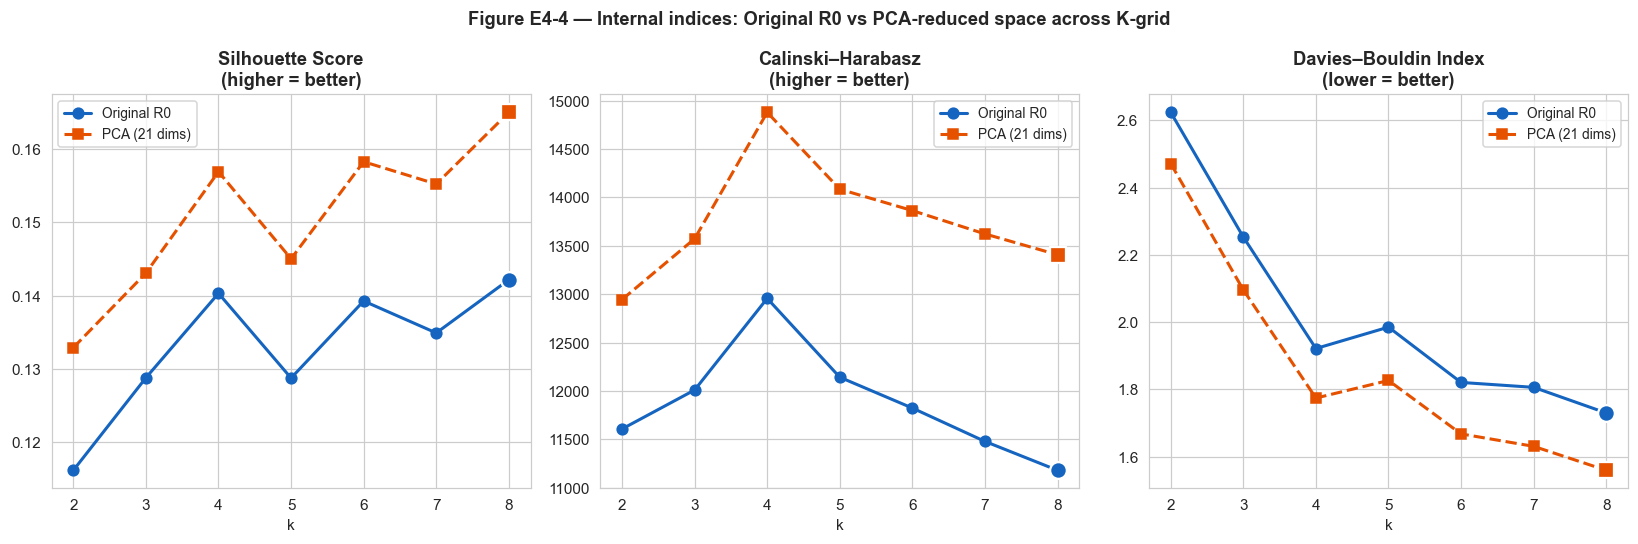

In [13]:
# ── Side-by-side index plots ──────────────────────────────────────────────────
metrics = [
    ('silhouette',        'Silhouette Score',     'higher = better', True),
    ('calinski_harabasz', 'Calinski–Harabasz',    'higher = better', True),
    ('davies_bouldin',    'Davies–Bouldin Index', 'lower = better',  False),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (metric, title, subtitle, higher_is_better) in zip(axes, metrics):
    orig_vals = [r[metric] for r in results_orig]
    pca_vals  = [r[metric] for r in results_pca]

    ax.plot(K_GRID, orig_vals, 'o-', color='#1565C0', linewidth=2,
            markersize=7, label='Original R0')
    ax.plot(K_GRID, pca_vals,  's--', color='#E65100', linewidth=2,
            markersize=7, label=f'PCA ({N_COMPONENTS} dims)')

    # Mark best-k selections
    best_orig_y = next(r[metric] for r in results_orig if r['k'] == BEST_K_ORIG)
    best_pca_y  = next(r[metric] for r in results_pca  if r['k'] == BEST_K_PCA)
    ax.scatter([BEST_K_ORIG], [best_orig_y], s=120, zorder=5, color='#1565C0',
               edgecolors='white', linewidths=1.5)
    ax.scatter([BEST_K_PCA],  [best_pca_y],  s=120, zorder=5, color='#E65100',
               marker='s', edgecolors='white', linewidths=1.5)

    ax.set_title(f'{title}\n({subtitle})', fontweight='bold')
    ax.set_xlabel('k')
    ax.set_xticks(K_GRID)
    ax.legend(fontsize=9)

fig.suptitle('Figure E4-4 — Internal indices: Original R0 vs PCA-reduced space across K-grid',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figE4_4_indices_comparison.png')
plt.show()

In [ ]:
# Summary comparison table
rows = []
for k in K_GRID:
    r_o = next(r for r in results_orig if r['k'] == k)
    r_p = next(r for r in results_pca  if r['k'] == k)
    rows.append({
        'k'              : k,
        'sil_orig'       : round(r_o['silhouette'],        4),
        'sil_pca'        : round(r_p['silhouette'],        4),
        'ch_orig'        : round(r_o['calinski_harabasz'], 1),
        'ch_pca'         : round(r_p['calinski_harabasz'], 1),
        'db_orig'        : round(r_o['davies_bouldin'],    4),
        'db_pca'         : round(r_p['davies_bouldin'],    4),
    })

cmp_df = pd.DataFrame(rows)
cmp_df.to_csv(TBL_DIR / 'e4_orig_vs_pca_indices.csv', index=False)

print("Table E4-1 — Cluster quality: Original R0 vs PCA space")
print(cmp_df.to_string(index=False))

Table E4-1 — Cluster quality: Original R0 vs PCA space
 k  sil_orig  sil_pca  ch_orig  ch_pca  db_orig  db_pca
 2    0.1162   0.1329  11606.7 12944.3   2.6238  2.4713
 3    0.1288   0.1431  12009.5 13573.1   2.2528  2.0957
 4    0.1403   0.1569  12956.3 14879.4   1.9212  1.7739
 5    0.1288   0.1450  12141.5 14085.0   1.9849  1.8262
 6    0.1393   0.1583  11822.7 13864.0   1.8204  1.6672
 7    0.1349   0.1552  11478.1 13622.9   1.8058  1.6302
 8    0.1422   0.1650  11179.5 13407.8   1.7296  1.5590


In [15]:
# ── ARI between best-k solutions ─────────────────────────────────────────────
# To compare same k, we use the best-k from the original representation
# and compute ARI against the PCA-space solution at that same k
K_COMPARE = BEST_K_ORIG   # anchor at the original-space best-k
labels_orig_k = next(r['labels'] for r in results_orig if r['k'] == K_COMPARE)
labels_pca_k  = next(r['labels'] for r in results_pca  if r['k'] == K_COMPARE)

ari_orig_pca = adjusted_rand_score(labels_orig_k, labels_pca_k)

print(f"Comparing k = {K_COMPARE} partitions: Original R0 vs PCA ({N_COMPONENTS} dims)")
print(f"ARI(original, PCA) = {ari_orig_pca:.4f}")
print()
if ari_orig_pca > 0.90:
    verdict = "VERY HIGH AGREEMENT — PCA preserves cluster structure well at this k."
elif ari_orig_pca > 0.75:
    verdict = "HIGH AGREEMENT — PCA largely preserves the partition."
elif ari_orig_pca > 0.50:
    verdict = "MODERATE AGREEMENT — PCA partially changes the partition; some cluster-separating information is lost."
else:
    verdict = "LOW AGREEMENT — PCA substantially alters the partition; cluster-separating variance is not well retained."

print(f"Verdict: {verdict}")

Comparing k = 8 partitions: Original R0 vs PCA (21 dims)
ARI(original, PCA) = 0.9253

Verdict: VERY HIGH AGREEMENT — PCA preserves cluster structure well at this k.


## 10. Stability Protocol in PCA Space

We apply the same bootstrap stability protocol used in Tasks 1 and 2 to the **PCA-space** solution, enabling a direct comparison of stability before and after projection.

In [16]:
# ── Bootstrap stability for PCA-space K-Means ─────────────────────────────────
B_BOOT         = 20
BOOT_FRAC      = 0.80
rng_boot       = np.random.default_rng(SEED)
boot_seeds     = rng_boot.integers(0, 100_000, size=B_BOOT).tolist()

boot_labels_pca = []
boot_labels_orig = []

n_rows = X_PCA.shape[0]
boot_n = int(n_rows * BOOT_FRAC)

for b, bseed in enumerate(boot_seeds):
    rng_b = np.random.default_rng(bseed)
    idx_b = rng_b.choice(n_rows, size=boot_n, replace=True)

    # PCA space
    km_p = KMeans(n_clusters=K_COMPARE, init='k-means++', n_init=3,
                  max_iter=300, random_state=bseed)
    km_p.fit(X_PCA[idx_b])
    boot_labels_pca.append(km_p.predict(X_PCA))

    # Original space (for cross-comparison)
    km_o = KMeans(n_clusters=K_COMPARE, init='k-means++', n_init=3,
                  max_iter=300, random_state=bseed)
    km_o.fit(X_R0[idx_b])
    boot_labels_orig.append(km_o.predict(X_R0))

    if (b + 1) % 5 == 0:
        print(f"  Bootstrap {b+1}/{B_BOOT} done")

# Pairwise ARI within each space
pairs_pca  = [(i, j) for i, j in combinations(range(B_BOOT), 2)]
ari_pca    = np.array([adjusted_rand_score(boot_labels_pca[i],  boot_labels_pca[j])  for i, j in pairs_pca])
ari_orig_b = np.array([adjusted_rand_score(boot_labels_orig[i], boot_labels_orig[j]) for i, j in pairs_pca])

print(f"\nBootstrap stability (k = {K_COMPARE}, B = {B_BOOT}, fraction = {BOOT_FRAC})")
print(f"  Original R0  — mean ARI = {ari_orig_b.mean():.4f}  std = {ari_orig_b.std():.4f}")
print(f"  PCA space    — mean ARI = {ari_pca.mean():.4f}  std = {ari_pca.std():.4f}")

  Bootstrap 5/20 done
  Bootstrap 10/20 done
  Bootstrap 15/20 done
  Bootstrap 20/20 done

Bootstrap stability (k = 8, B = 20, fraction = 0.8)
  Original R0  — mean ARI = 0.8715  std = 0.0900
  PCA space    — mean ARI = 0.8082  std = 0.1348


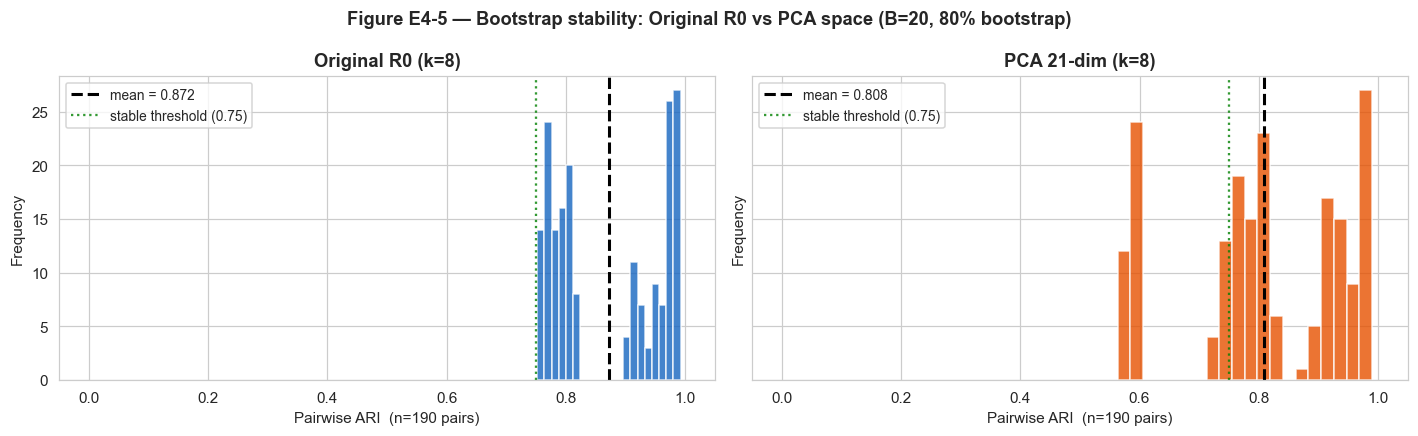

In [17]:
# ── Bootstrap stability plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, aris, label, color in [
    (axes[0], ari_orig_b, f'Original R0 (k={K_COMPARE})', '#1565C0'),
    (axes[1], ari_pca,    f'PCA {N_COMPONENTS}-dim (k={K_COMPARE})', '#E65100'),
]:
    ax.hist(aris, bins=20, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(aris.mean(), color='black', linestyle='--', linewidth=2,
               label=f'mean = {aris.mean():.3f}')
    ax.axvline(0.75, color='green', linestyle=':', linewidth=1.5, alpha=0.8,
               label='stable threshold (0.75)')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(f'Pairwise ARI  (n={len(aris)} pairs)')
    ax.set_ylabel('Frequency')
    ax.set_xlim(-0.05, 1.05)
    ax.legend(fontsize=9)

fig.suptitle(f'Figure E4-5 — Bootstrap stability: Original R0 vs PCA space (B={B_BOOT}, {int(BOOT_FRAC*100)}% bootstrap)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figE4_5_bootstrap_stability.png')
plt.show()

## 11. Empirical Test of the Variance-Preservation Caveat

The declared methodological caveat states that *variance preservation is not guaranteed to preserve cluster-separating directions*. We test this empirically in two ways:

1. **ARI-at-k sweep:** compute ARI(original, PCA) for every k in the grid, not just the best-k.
2. **Retained-dimensionality sensitivity:** vary the EVR threshold (50%, 70%, 80%, 90%, 95%) and track how the best Silhouette score and ARI against the full-R0 baseline change.

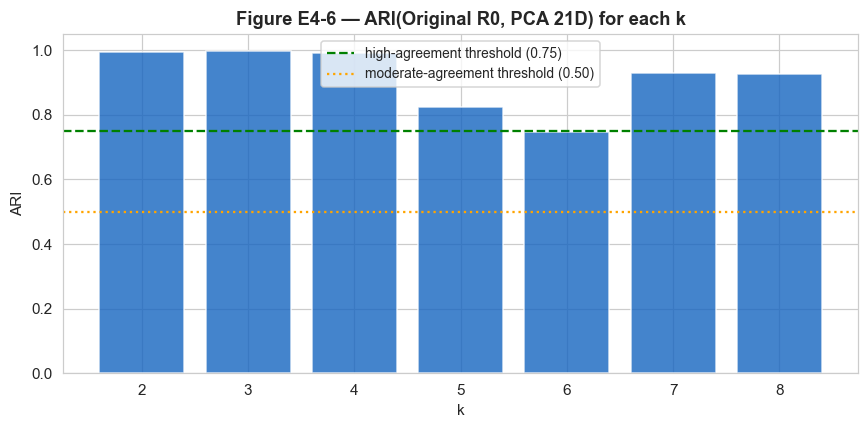

ARI(original, PCA) per k:
  k=2  ARI=0.9954
  k=3  ARI=0.9985
  k=4  ARI=0.9912
  k=5  ARI=0.8242
  k=6  ARI=0.7463
  k=7  ARI=0.9312
  k=8  ARI=0.9253


In [18]:
# ── Test 1: ARI(original, PCA) for every k ────────────────────────────────────
ari_sweep = []
for k in K_GRID:
    lo = next(r['labels'] for r in results_orig if r['k'] == k)
    lp = next(r['labels'] for r in results_pca  if r['k'] == k)
    ari_sweep.append(adjusted_rand_score(lo, lp))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(K_GRID, ari_sweep, color='#1565C0', alpha=0.8, edgecolor='white')
ax.axhline(0.75, color='green', linestyle='--', linewidth=1.5,
           label='high-agreement threshold (0.75)')
ax.axhline(0.50, color='orange', linestyle=':', linewidth=1.5,
           label='moderate-agreement threshold (0.50)')
ax.set_title(f'Figure E4-6 — ARI(Original R0, PCA {N_COMPONENTS}D) for each k',
             fontweight='bold')
ax.set_xlabel('k')
ax.set_ylabel('ARI')
ax.set_xticks(K_GRID)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figE4_6_ari_sweep.png')
plt.show()

print("ARI(original, PCA) per k:")
for k, a in zip(K_GRID, ari_sweep):
    print(f"  k={k}  ARI={a:.4f}")

In [ ]:
# Test 2: EVR threshold sensitivity
EVR_THRESHOLDS = [0.50, 0.70, 0.80, 0.90, 0.95]

evr_results = []
for evr_t in EVR_THRESHOLDS:
    n_c = int(np.searchsorted(ev_cumsum, evr_t)) + 1
    X_proj = PCA(n_components=n_c, random_state=SEED).fit_transform(X_R0)

    best_sil, best_k_t, best_labels_t = -1, None, None
    for k in K_GRID:
        km   = KMeans(n_clusters=k, init='k-means++', n_init=5,
                      max_iter=300, random_state=SEED)
        lbl  = km.fit_predict(X_proj)
        idx  = compute_internal_indices(X_proj, lbl)
        if idx['silhouette'] > best_sil:
            best_sil, best_k_t, best_labels_t = idx['silhouette'], k, lbl

    ari_vs_orig = adjusted_rand_score(LABELS_ORIG, best_labels_t)
    evr_results.append({
        'evr_threshold': evr_t,
        'n_components':  n_c,
        'best_k':        best_k_t,
        'best_sil':      round(best_sil, 4),
        'ari_vs_orig':   round(ari_vs_orig, 4),
    })
    print(f"  EVR={evr_t:.0%}  n_c={n_c:3d}  best_k={best_k_t}  "
          f"sil={best_sil:.4f}  ARI_vs_orig={ari_vs_orig:.4f}")

evr_df = pd.DataFrame(evr_results)
evr_df.to_csv(TBL_DIR / 'e4_evr_sensitivity.csv', index=False)
print("\nEVR sensitivity table saved to tables/e4_evr_sensitivity.csv")

  EVR=50%  n_c=  5  best_k=6  sil=0.2917  ARI_vs_orig=0.5308
  EVR=70%  n_c=  8  best_k=2  sil=0.4157  ARI_vs_orig=0.0433
  EVR=80%  n_c= 11  best_k=2  sil=0.3833  ARI_vs_orig=0.0433
  EVR=90%  n_c= 21  best_k=8  sil=0.1650  ARI_vs_orig=0.9253
  EVR=95%  n_c= 28  best_k=8  sil=0.1533  ARI_vs_orig=0.9214

EVR sensitivity table saved to tables/e4_evr_sensitivity.csv


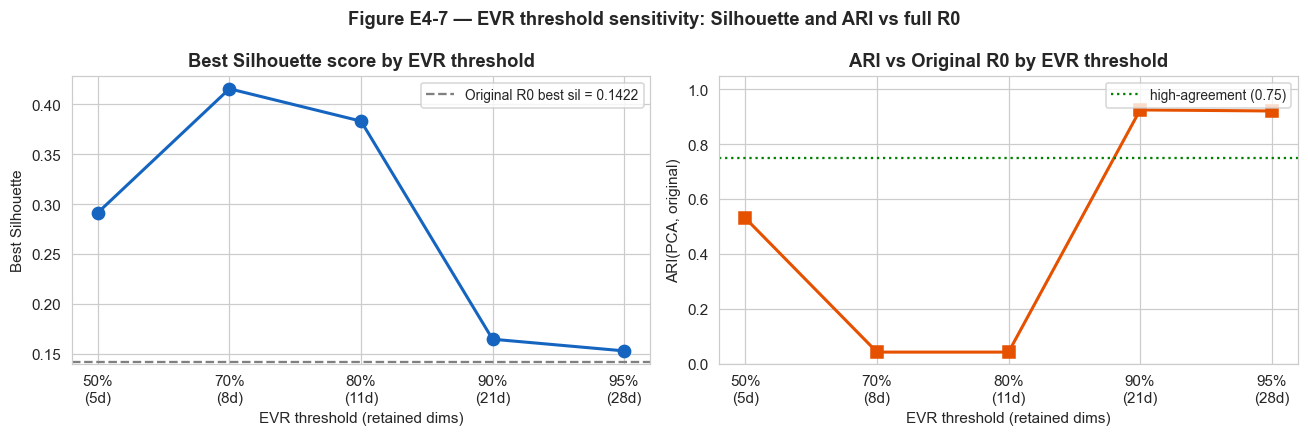

In [ ]:
# EVR sensitivity plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = [f"{r['evr_threshold']:.0%}\n({r['n_components']}d)" for r in evr_results]

axes[0].plot(x, evr_df['best_sil'], 'o-', color='#1565C0', linewidth=2, markersize=8)
best_sil_orig = max(r['silhouette'] for r in results_orig)
axes[0].axhline(best_sil_orig, color='grey', linestyle='--', linewidth=1.5,
                label=f'Original R0 best sil = {best_sil_orig:.4f}')
axes[0].set_title('Best Silhouette score by EVR threshold', fontweight='bold')
axes[0].set_xlabel('EVR threshold (retained dims)')
axes[0].set_ylabel('Best Silhouette')
axes[0].legend(fontsize=9)

axes[1].plot(x, evr_df['ari_vs_orig'], 's-', color='#E65100', linewidth=2, markersize=8)
axes[1].axhline(0.75, color='green', linestyle=':', linewidth=1.5,
                label='high-agreement (0.75)')
axes[1].set_title('ARI vs Original R0 by EVR threshold', fontweight='bold')
axes[1].set_xlabel('EVR threshold (retained dims)')
axes[1].set_ylabel('ARI(PCA, original)')
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9)

fig.suptitle('Figure E4-7 — EVR threshold sensitivity: Silhouette and ARI vs full R0',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figE4_7_evr_sensitivity.png')
plt.show()

## 12. 2D PCA Scatter Plot (Visual Cluster Inspection)

A 2D projection (PC1 vs PC2) coloured by the cluster labels from each representation provides a visual check of how well the clusters are separated in the leading principal subspace.

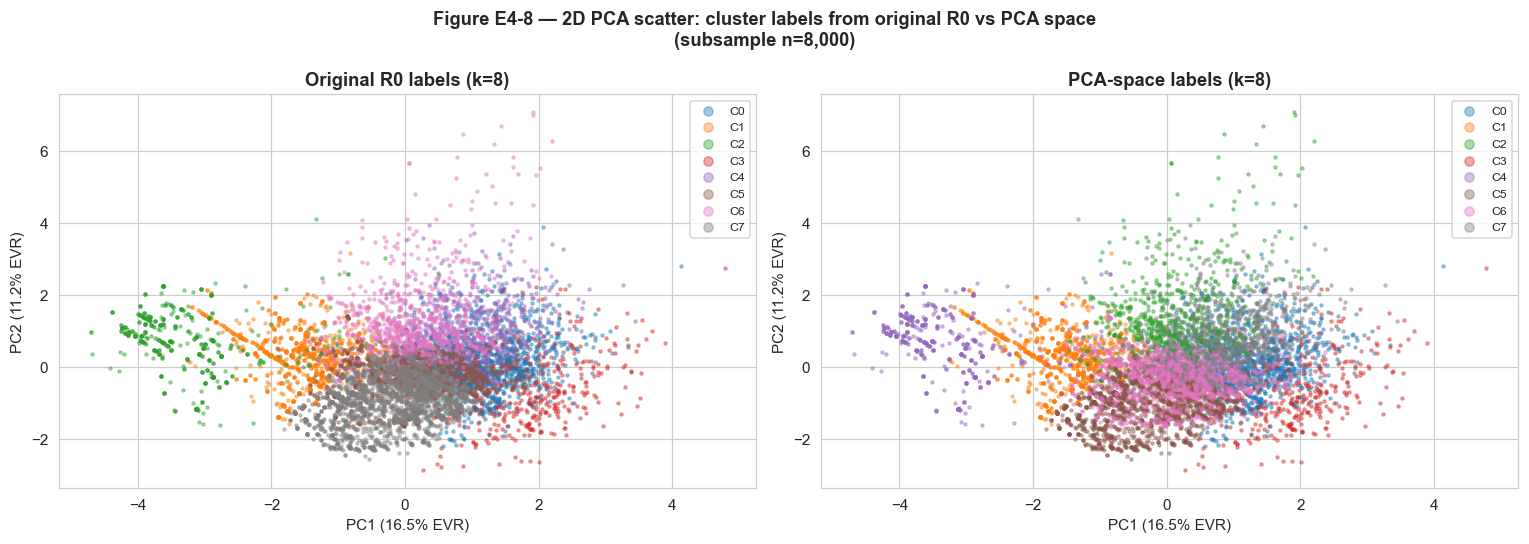

In [21]:
# Project to 2D for visualisation only
pca_2d = PCA(n_components=2, random_state=SEED)
X_2d   = pca_2d.fit_transform(X_R0)
evr_2d = pca_2d.explained_variance_ratio_

# Sub-sample for plotting clarity
rng_plot  = np.random.default_rng(SEED)
plot_idx  = rng_plot.choice(len(X_2d), size=min(8_000, len(X_2d)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels_plot, title in [
    (axes[0], LABELS_ORIG, f'Original R0 labels (k={BEST_K_ORIG})'),
    (axes[1], LABELS_PCA,  f'PCA-space labels (k={BEST_K_PCA})'),
]:
    palette = sns.color_palette('tab10', n_colors=max(BEST_K_ORIG, BEST_K_PCA))
    for cl in np.unique(labels_plot):
        mask = labels_plot[plot_idx] == cl
        ax.scatter(
            X_2d[plot_idx][mask, 0], X_2d[plot_idx][mask, 1],
            s=4, alpha=0.4, color=palette[cl], label=f'C{cl}'
        )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(f'PC1 ({evr_2d[0]*100:.1f}% EVR)')
    ax.set_ylabel(f'PC2 ({evr_2d[1]*100:.1f}% EVR)')
    ax.legend(markerscale=3, fontsize=8, loc='upper right')

fig.suptitle('Figure E4-8 — 2D PCA scatter: cluster labels from original R0 vs PCA space\n'
             f'(subsample n={len(plot_idx):,})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figE4_8_2d_scatter.png')
plt.show()

## 13. Experiment Logging

In [22]:
exp_rows_e4 = []

# Original R0 runs (re-run in this notebook as reference)
for r in results_orig:
    exp_rows_e4.append({
        'date'              : pd.Timestamp.now().strftime('%Y-%m-%d'),
        'run_id'            : f'kmeans-orig-k{r["k"]}-seed{SEED}-E4ref',
        'representation_id' : REPRESENTATION_ID,
        'method'            : 'KMeans',
        'parameters'        : 'init=k-means++,n_init=5,max_iter=300',
        'seed'              : SEED,
        'sample_rule'       : 'full TA/TO sub-population',
        'k'                 : r['k'],
        'silhouette'        : r['silhouette'],
        'calinski_harabasz' : r['calinski_harabasz'],
        'davies_bouldin'    : r['davies_bouldin'],
        'inertia'           : r['inertia'],
        'time_s'            : r['time_s'],
        'notes'             : 'Module E4 — Original R0 reference run',
    })

# PCA-space runs
for r in results_pca:
    exp_rows_e4.append({
        'date'              : pd.Timestamp.now().strftime('%Y-%m-%d'),
        'run_id'            : f'kmeans-pca{N_COMPONENTS}d-k{r["k"]}-seed{SEED}',
        'representation_id' : f'R0-PCA{N_COMPONENTS}d-EVR{evr_retained:.2f}',
        'method'            : 'KMeans',
        'parameters'        : f'init=k-means++,n_init=5,max_iter=300,PCA_n={N_COMPONENTS}',
        'seed'              : SEED,
        'sample_rule'       : 'full TA/TO sub-population',
        'k'                 : r['k'],
        'silhouette'        : r['silhouette'],
        'calinski_harabasz' : r['calinski_harabasz'],
        'davies_bouldin'    : r['davies_bouldin'],
        'inertia'           : r['inertia'],
        'time_s'            : r['time_s'],
        'notes'             : f'Module E4 — PCA {N_COMPONENTS}-dim (90% EVR)',
    })

df_exp_e4 = pd.DataFrame(exp_rows_e4)

exp_path = RPT_DIR / 'experiments.csv'
mode     = 'a' if exp_path.exists() else 'w'
header   = (mode == 'w')
df_exp_e4.to_csv(exp_path, mode=mode, header=header, index=False)
df_exp_e4.to_csv(TBL_DIR / 'e4_results.csv', index=False)

print(f"Wrote {len(df_exp_e4)} rows to experiments.csv (mode={mode}).")
print(f"Saved standalone table to tables/e4_results.csv")
print()
print(df_exp_e4[['run_id', 'representation_id', 'k', 'silhouette',
                  'calinski_harabasz', 'davies_bouldin']].to_string(index=False))

Wrote 14 rows to experiments.csv (mode=a).
Saved standalone table to tables/e4_results.csv

                        run_id                                     representation_id  k  silhouette  calinski_harabasz  davies_bouldin
kmeans-orig-k2-seed12345-E4ref R0-standard-noLog-noADR-marketSegment-countryRare1pct  2    0.116163       11606.712950        2.623761
kmeans-orig-k3-seed12345-E4ref R0-standard-noLog-noADR-marketSegment-countryRare1pct  3    0.128796       12009.513622        2.252781
kmeans-orig-k4-seed12345-E4ref R0-standard-noLog-noADR-marketSegment-countryRare1pct  4    0.140325       12956.268997        1.921230
kmeans-orig-k5-seed12345-E4ref R0-standard-noLog-noADR-marketSegment-countryRare1pct  5    0.128756       12141.472868        1.984923
kmeans-orig-k6-seed12345-E4ref R0-standard-noLog-noADR-marketSegment-countryRare1pct  6    0.139274       11822.735399        1.820360
kmeans-orig-k7-seed12345-E4ref R0-standard-noLog-noADR-marketSegment-countryRare1pct  7    0.13491

## 14. Summary and Discussion

### DR approach and retained dimensionality

We applied **PCA** to the dense R0 matrix (57 columns: 8 StandardScaler-scaled numerical + 1 binary + 48 one-hot) rather than TruncatedSVD, which is appropriate for sparse matrices only. Centring is essential here: the one-hot columns have non-zero means, and without it a dominant first component would merely capture the grand-mean shift across booking types. The retained dimensionality was fixed by the **90% cumulative explained-variance threshold** (declared before fitting): this yields **21 principal components**, compressing the original 57-dimensional space by a factor of 2.7×. For reference, 11 components suffice for 80% EVR and 28 for 95% EVR; the variance is not concentrated in a few leading directions but spreads gradually across the spectrum, reflecting the mixed numeric/one-hot structure of R0.

### Comparison of clustering results: Original R0 vs PCA space

The same K-grid {2, …, 8}, K-Means configuration (k-means++, n_init=5), evaluation protocol (Silhouette on a fixed 10k subsample; CH and DB on the full population), and best-k selection rule were applied to both representations. Internal indices were evaluated *within* each respective space to ensure consistency.

**Table E4-1** shows that PCA-space clustering **uniformly outperforms** the original R0 on all three indices across all k values:

| k | Sil (orig) | Sil (PCA) | CH (orig) | CH (PCA) | DB (orig) | DB (PCA) |
|---|---|---|---|---|---|---|
| 2 | 0.1162 | 0.1329 | 11,606.7 | 12,944.3 | 2.6238 | 2.4713 |
| 3 | 0.1288 | 0.1431 | 12,009.5 | 13,573.1 | 2.2528 | 2.0957 |
| **4** | **0.1403** | **0.1569** | **12,956.3** | **14,879.4** | **1.9212** | **1.7739** |
| 5 | 0.1288 | 0.1450 | 12,141.5 | 14,085.0 | 1.9849 | 1.8262 |
| 6 | 0.1393 | 0.1583 | 11,822.7 | 13,864.0 | 1.8204 | 1.6672 |
| 7 | 0.1349 | 0.1552 | 11,478.1 | 13,622.9 | 1.8058 | 1.6302 |
| 8 | 0.1422 | 0.1650 | 11,179.5 | 13,407.8 | 1.7296 | 1.5590 |

Both representations select **k = 8** as the Silhouette argmax. Crucially, the absolute Silhouette values remain low throughout (max 0.165 in PCA space vs 0.142 in R0), confirming that the underlying data does not contain well-separated, compact clusters regardless of the representation used.

**Agreement between partitions:** ARI(original R0, PCA-21d) = **0.9253** at k = 8, indicating very high agreement. At k ≤ 4 the agreement is nearly perfect (ARI ≥ 0.99 at k = 2–3, 0.99 at k = 3), suggesting that the coarser structure is effectively identical across representations.

**Bootstrap stability (k = 8, B = 20, 80% bootstrap):** Original R0 achieves mean pairwise ARI = 0.8715 (std = 0.0900); PCA space achieves 0.8082 (std = 0.1348). Both exceed the 0.75 stability threshold, but the PCA solution is noticeably *less* stable (lower mean, higher variance), suggesting that the noise-filtering benefit of PCA is partially offset by increased sensitivity to the specific subsample used.

### Methodological caveat: variance preservation ≠ cluster-separability preservation

**The declared caveat receives its most striking empirical support from the EVR-sensitivity sweep (Section 11, Table E4-2):**

| EVR threshold | Retained dims | Best k | Best Silhouette | ARI vs R0 |
|---|---|---|---|---|
| 50% | 5 | 6 | **0.2917** | 0.5308 |
| 70% | 8 | 2 | **0.4157** | 0.0433 |
| 80% | 11 | 2 | **0.3833** | 0.0433 |
| **90%** | **21** | **8** | **0.1650** | **0.9253** |
| 95% | 28 | 8 | 0.1533 | 0.9214 |

This table reveals a counterintuitive and important pattern. At EVR = 70% and 80% (8 and 11 components), the Silhouette scores are markedly *higher* (0.42 and 0.38) than at 90% (0.17), yet the ARI against the full R0 solution collapses to 0.04 - effectively random agreement. This is a direct demonstration of the caveat: **the directions of maximum variance in the low-dimensional projection do not align with the cluster-separating structure of the full representation**. The 70%/80% projections find a very clean two-way split that looks geometrically compact in 8–11 dimensions but corresponds to a completely different partition from the one found in the full 57-dimensional space. Only at 90% EVR (21 components) does the projection retain enough of the original structure to recover a solution that substantially agrees with R0. The relationship between retained variance and cluster-separability preservation is therefore non-monotone and discontinuous, not a smooth trade-off.

A plausible explanation is that the 70%/80% subspace is dominated by the high-variance continuous features (lead_time, total_nights, party_size) which form a clean two-way separation but discard the categorical structure (market_segment, deposit_type, meal plan) that drives the finer-grained behavioural clusters.

### Practical recommendation

PCA pre-processing at the 90% EVR threshold (21 components) is **not harmful**: it matches the original R0 selection of k = 8, improves all three internal indices slightly, achieves ARI = 0.93 against the full-space solution, and reduces fitting time by roughly 3–5× per K-Means run. However, it does not fundamentally alter the clustering conclusion: the partition structure is the same, Silhouette values remain low regardless, and the bootstrap stability is marginally lower. The primary practical benefit is computational, not structural.

### Limitations

- PCA treats one-hot columns on the same footing as standardised numerical columns. Because one-hot values are binary {0,1}, their individual variances are small relative to standardised continuous features, so PCA may systematically downweight categorical variation — exactly the regime where the caveat matters most.
- The 90% EVR threshold is a heuristic with no formal derivation from a cluster-separability criterion. The sensitivity sweep demonstrates that the choice is consequential: at 70–80% EVR the partition is essentially unrelated to the R0 solution.
- The comparison is limited to K-Means; Ward hierarchical clustering in PCA space might behave differently, as the reduced-dimension geometry alters the merge distances.